In [7]:
# Cell 1: Import necessary libraries

import os
import numpy as np
import time
from pydrake.all import (
    DiagramBuilder, AddMultibodyPlantSceneGraph, Parser,
    Role, MeshcatVisualizer, StartMeshcat, RationalForwardKinematics, CspaceFreePolytope,
    SeparatingPlaneOrder, Rgba, RollPitchYaw,
    LinearEqualityConstraint, Sphere, Parallelism, AddDefaultVisualization, 
    ConnectPlanarSceneGraphVisualizer, IrisFromCliqueCoverOptions, 
    CommonSampledIrisOptions, IrisZoOptions, IrisNp2Options,
    IrisInConfigurationSpaceFromCliqueCover, RandomGenerator, RobotDiagramBuilder, 
    SceneGraphCollisionChecker, MultibodyPlant, SceneGraph, 
    SolverOptions, CommonSolverOption, GeometrySet, ScsSolver
)
from pydrake.geometry.optimization import GraphOfConvexSetsOptions, HPolyhedron, VPolytope, Point, Hyperellipsoid
from pydrake.geometry.optimization import ConvexHull as DrakeConvexHull
from pydrake.planning import GcsTrajectoryOptimization
from pydrake.solvers import MathematicalProgram, Solve, MosekSolver
from pydrake.trajectories import CompositeTrajectory
from pydrake.common import FindResourceOrThrow
from scipy.spatial import ConvexHull
from pydrake.math import RigidTransform, RotationMatrix
from pydrake.multibody.inverse_kinematics import InverseKinematics
from pydrake.solvers import Solve, SnoptSolver, IpoptSolver, OsqpSolver, ScsSolver
import mcubes
from functools import partial
import matplotlib.pyplot as plt
from ipywidgets import widgets
import quadprog
from dataclasses import dataclass

from pathlib import Path
import sys

# add the parent directory of this notebook to the import path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))

from ciris_plant_visualizer import CIrisPlantVisualizer

In [8]:
!pip show drake

Name: drake
Version: 1.48.0
Summary: Model-based design and verification for robotics
Home-page: https://drake.mit.edu
Author: Drake Development Team
Author-email: drake-users@mit.edu
License: Various
Location: /home/julialopezgomez/miniforge3/envs/obmp/lib/python3.13/site-packages
Requires: matplotlib, Mosek, numpy, pydot, PyYAML
Required-by: 


In [9]:
# Cell 2: Set up the plant and scene graph, and initialize the CIrisPlantVisualizer
# builder = DiagramBuilder()
# plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
# parser = Parser(plant, scene_graph)
# parser.SetAutoRenaming(True)

print("Setting up the plant and scene graph...")

# Replace DiagramBuilder with RobotDiagramBuilder
builder = RobotDiagramBuilder(time_step=0.0)
plant = builder.plant()
scene_graph = builder.scene_graph()
parser = Parser(plant, scene_graph)
parser.SetAutoRenaming(True)

Setting up the plant and scene graph...


In [10]:
# Add the robot
# gripper = parser.AddModels(file_name="../my_sdfs/wsg_2dof.sdf")[0]

print("Loading Panda robot models...")

# --- Add the Panda arm + hand ---
panda_arm  = parser.AddModels(url="package://drake_models/franka_description/urdf/panda_arm.urdf")[0]
# panda_arm  = parser.AddModels(url="file:///home/julialopezgomez/optimisation-based-manipulation-planner/my_sdfs/panda_arm.urdf")[0]
panda_hand = parser.AddModels(url="package://drake_models/franka_description/urdf/panda_hand.urdf")[0]
# panda_arm  = parser.AddModels(url="file:///home/julialopezgomez/optimisation-based-manipulation-planner/my_sdfs/panda_arm_locked.urdf")[0]
# panda_hand = parser.AddModels(url="file:///home/julialopezgomez/optimisation-based-manipulation-planner/my_sdfs/panda_hand_locked.urdf")[0]

print("Welding Panda arm and hand...")

# Weld arm base to world (identity)
plant.WeldFrames(
    plant.world_frame(),
    plant.GetFrameByName("panda_link0", panda_arm),
    RigidTransform())

# Weld hand to arm flange with X_PC: translation [0,0,0], RPY deg [0,0,-45]
X_8H = RigidTransform(RollPitchYaw(0.0, 0.0, -np.deg2rad(45.0)), [0.0, 0.0, 0.0])
plant.WeldFrames(
    plant.GetFrameByName("panda_link8", panda_arm),        # parent (P)
    plant.GetFrameByName("panda_hand", panda_hand),    # child  (C)
    X_8H)

print("Setting default finger joint positions...")

# Optional: set the default finger opening (each finger is a prismatic joint).
# 0.02 m on each finger → ~0.04 m total width. Adjust to taste.
for j in ["panda_finger_joint1"]:#, "panda_finger_joint2"]:
    plant.GetJointByName(j, panda_hand).set_default_translation(-0.024)
    

    


Loading Panda robot models...
Welding Panda arm and hand...
Setting default finger joint positions...


In [11]:
print("Adding the bottle cap and obstacles...")

cap = parser.AddModels(file_name="../my_sdfs/bottle_cap.sdf")[0]
obstacle1 = parser.AddModels("../my_sdfs/obstacle.sdf")[0]
# obstacle2 = parser.AddModels("my_sdfs/obstacle.sdf")[0]
obstacle3 = parser.AddModels("../my_sdfs/obstacle.sdf")[0]

# Set welds
plant.WeldFrames(
    plant.world_frame(), 
    plant.GetFrameByName("base_link", cap),
    RigidTransform(RotationMatrix(), [0.5, 0, 0]))

# Weld the obstacle to the world frame (adjust pose as needed)
obstacle_pose1 = RigidTransform(RotationMatrix(), [0.51, 0.031, 0.01])  # Adjust position
plant.WeldFrames(
    plant.world_frame(),
    plant.GetFrameByName("obstacle_link", obstacle1),
    obstacle_pose1)

# # obstacle_pose2 = RigidTransform(RotationMatrix(), [-0.025, 0.05, 0.01])  # Adjust position
# # plant.WeldFrames(
# #     plant.world_frame(),
# #     plant.GetFrameByName("obstacle_link", obstacle2),
# #     obstacle_pose2)

obstacle_pose3 = RigidTransform(RotationMatrix(), [0.467, -0.005, 0.01])  # Adjust position
plant.WeldFrames(
    plant.world_frame(),
    plant.GetFrameByName("obstacle_link", obstacle3),
    obstacle_pose3)

Adding the bottle cap and obstacles...


<WeldJoint name='world_welds_to_obstacle_link' index=16 model_instance=6>

In [12]:
print("Finalising plant...")
print("Bodies:", plant.num_bodies(), "Joints:", plant.num_joints())


plant.Finalize()

inspector = scene_graph.model_inspector()
num_frames = len(list(inspector.GetAllFrameIds()))
num_geoms = sum(inspector.NumGeometriesForFrame(fid) for fid in inspector.GetAllFrameIds())
print("Frames:", num_frames, "Geometries:", num_geoms)


print("Plant finalised.")

print("Number of positions: ", plant.num_positions())

# Cell 3: Initialize the CIrisPlantVisualizer
q_star = np.zeros(plant.num_positions())


print("Initialising CspaceFreePolytope...")

# The object we will use to perform our certification
cspace_free_polytope = CspaceFreePolytope(
    plant, 
    scene_graph,
    SeparatingPlaneOrder.kAffine,
    q_star)

print("Initializing CIrisPlantVisualizer...")

visualizer = CIrisPlantVisualizer(
    plant,
    builder,
    scene_graph,
    cspace_free_polytope,
    viz_role=Role.kIllustration,
    # viz_role=Role.kProximity,
    allow_plus_3dof=True
)

print("Setting up the visualizer...")

visualizer.task_space_diagram.ForcedPublish(visualizer.task_space_diagram_context)


INFO:drake:Meshcat listening for connections at http://localhost:7001


Finalising plant...
Bodies: 18 Joints: 17
Frames: 18 Geometries: 94
Plant finalised.
Number of positions:  10
Initialising CspaceFreePolytope...
Initializing CIrisPlantVisualizer...
Visualisations won't work properly. Can't visualize the TC-Space of plants with more than 3-DOF. The first 3 DOF from the plant will be visualized
Setting up the visualizer...


In [13]:

sliders = []

plant_context = visualizer.plant_context
diagram = visualizer.task_space_diagram
diagram_context = visualizer.task_space_diagram_context

for i in range(plant.num_positions()):
    q_low = plant.GetPositionLowerLimits()[i]
    q_high = plant.GetPositionUpperLimits()[i]
    step = (q_high - q_low) / 100
    sliders.append(widgets.FloatSlider(
        min=q_low, max=q_high, 
        value=0, step=step, 
        description=f"q{i}"))
    
q = np.zeros(plant.num_positions())

def report_collisions(q):
    plant.SetPositions(plant_context, q)
    query_object = scene_graph.get_query_output_port().Eval(
        scene_graph.GetMyContextFromRoot(diagram_context)
    )
    inspector = scene_graph.model_inspector()

    pairs = query_object.ComputePointPairPenetration()
    if not pairs:
        print("No penetrations")
        return

    for pair in pairs:
        name_A = inspector.GetName(pair.id_A)
        name_B = inspector.GetName(pair.id_B)
        print(f"{name_A} <-> {name_B}, depth={pair.depth}")



out = widgets.Output()
display(out)

def handle_slider_change(change, idx):
    q[idx] = change["new"]
    plant.SetPositions(plant_context, q)
    diagram.ForcedPublish(diagram_context)
    with out:
        out.clear_output(wait=True)
        
        report_collisions(q)
        print(f"{visualizer.check_collision_q_by_ik(q)} \t {q}", flush=True)
    
    
idx = 0
for slider in sliders:
    slider.observe(partial(handle_slider_change, idx = idx), names='value')
    idx+=1

for slider in sliders:
    display(slider)

Output()

FloatSlider(value=0.0, description='q0', max=2.8973, min=-2.8973, step=0.057946)

FloatSlider(value=0.0, description='q1', max=1.7628, min=-1.7628, step=0.035255999999999996)

FloatSlider(value=0.0, description='q2', max=2.8973, min=-2.8973, step=0.057946)

FloatSlider(value=-0.0698, description='q3', max=-0.0698, min=-3.0718, step=0.03002)

...

FloatSlider(value=0.0, description='q5', max=3.7525, min=-0.0175, step=0.0377)

FloatSlider(value=0.0, description='q6', max=2.8973, min=-2.8973, step=0.057946)

FloatSlider(value=0.0, description='q7', max=0.0, min=-0.045, step=0.00045)

FloatSlider(value=0.0, description='q8', max=0.045, step=0.00045)

FloatSlider(value=0.0, description='q9', max=3.14, min=-3.14, step=0.06280000000000001)

In [14]:
def joint_position_index(plant, joint_name, model_instance=None):
    if model_instance is None:
        joint = plant.GetJointByName(joint_name)
    else:
        joint = plant.GetJointByName(joint_name, model_instance)

    if joint.num_positions() != 1:
        raise ValueError(
            f"Joint {joint_name} has {joint.num_positions()} positions; "
            "this helper assumes a 1-DOF joint."
        )

    return joint.position_start()

for i, name in enumerate(plant.GetPositionNames()):
    print(f"{i:2d}: {name:40s}")



 0: panda_panda_joint1_q                    
 1: panda_panda_joint2_q                    
 2: panda_panda_joint3_q                    
 3: panda_panda_joint4_q                    
 4: panda_panda_joint5_q                    
 5: panda_panda_joint6_q                    
 6: panda_panda_joint7_q                    
 7: panda_hand_panda_finger_joint1_x        
 8: panda_hand_panda_finger_joint2_x        
 9: bottle_cap_cap_to_base_q                


## Find Grasping configuration

In [15]:
def solve_ik_place_frame_at_pose(
    # visualizer,
    plant,
    plant_context,
    hand_frame,                                # the frame you want to place (e.g., panda_hand)
    cap_frame,
    X_WG: RigidTransform,                   # desired pose of frame_B in world
    pos_tol=1e-3,                           # box half-width [m]
    theta_tol=np.deg2rad(2),                # angular tolerance [rad]
    axis_tol=1e-6,
    min_distance=None,                      # e.g., 1e-3 to keep clearance; None to ignore
    q_seed=None,                            # seed configuration
):
    
    ik = InverseKinematics(plant, plant_context)
    q = ik.q()

    # Position: keep the origin of frame_B in a small box around X_WG.translation()
    p_BQ_B = np.zeros(3)
    p = X_WG.translation()
    ik.AddPositionConstraint(
        frameB=hand_frame, p_BQ=p_BQ_B,
        frameA=plant.world_frame(),
        p_AQ_lower=p - pos_tol, p_AQ_upper=p + pos_tol
    )

#     # Orientation: bound frame_B’s rotation to the desired world rotation
#     # This constrains angle between R_WB and X_WG.rotation() to be <= theta_tol.    
#     ik.AddOrientationConstraint(
#     frameAbar=plant.world_frame(),            # Ā
#     R_AbarA=X_WG.rotation(),                  # desired world rotation
#     frameBbar=hand_frame,                        # B̄ = your hand frame
#     R_BbarB=RotationMatrix(),                 # identity in B
#     theta_bound=theta_tol                     # radians
# )

    ik.AddAngleBetweenVectorsConstraint(
        frameA=cap_frame,
        na_A=[0, 0, -1],  # z-axis of cap frame
        frameB=hand_frame,
        nb_B=[0, 0, 1],  # z-axis of hand frame
        angle_lower=0,
        angle_upper=axis_tol
    )


    # Optional collision clearance (uses Proximity role; can be conservative for grasps)
    if min_distance is not None:
        ik.AddMinimumDistanceLowerBoundConstraint(min_distance)

    prog = ik.prog()
    if q_seed is None:
        q_seed = plant.GetPositions(plant_context)
    prog.SetInitialGuess(q, q_seed)

    # Pick an available solver. Orientation makes this nonlinear; SNOPT/IPOPT are best.
    result = Solve(prog)
    if not result.is_success():
        # try a second pass with a looser theta or different seed before giving up
        return None, result

    q_sol = result.GetSolution(q)

    return q_sol, result


In [29]:
# Build diagram/contexts as you already do

# set meshcat and plant position at q np.zeros
# q0 = np.zeros(plant.num_positions())
# plant.SetPositions(plant_context, q0)
# diagram.ForcedPublish(diagram_context)

plant_context = visualizer.plant_context
diagram = visualizer.task_space_diagram
diagram_context = visualizer.task_space_diagram_context

# Frames and goal pose
# E   = plant.GetFrameByName("panda_hand", panda_hand)   # tool frame
E   = plant.GetFrameByName("panda_link8", panda_arm)   # tool frame
# E6   = plant.GetFrameByName("panda_link6", panda_arm)   # tool frame
Cap = plant.GetFrameByName("base_link", cap)           # cap frame

# World poses
X_WCap = plant.CalcRelativeTransform(plant_context, plant.world_frame(), Cap)

# Choose a grasp goal: 65 mm above cap origin (same orientation as Cap here)
# Rotate by 180 deg upside down
R_CapGoal = RotationMatrix(RollPitchYaw(np.pi, 0, 1.))
X_CapGoal = RigidTransform(R_CapGoal, [0.0, 0.0, 0.105])
X_WG = X_WCap.multiply(X_CapGoal)  # desired world pose for the hand frame

# (Optional) lock fingers during IK
# for jn in ["panda_finger_joint1", "panda_finger_joint2"]:
#     plant.GetJointByName(jn, panda_hand).Lock(plant_context)



# Solve IK (function from previous message)
q_sol, res = solve_ik_place_frame_at_pose(
    # visualizer=visualizer,
    plant=plant,
    plant_context=plant_context,
    hand_frame=E,
    cap_frame=Cap,
    X_WG=X_WG,
    pos_tol=0.0,
    theta_tol=np.deg2rad(0),
    axis_tol=0.0,
    min_distance=None,
    q_seed=plant.GetPositions(plant_context)
)



# (Optional) set joint finger positions to -0.024 and 0.024 respectively
q_sol[7] = -0.024
q_sol[8] = 0.024

if q_sol is None:
    print("IK failed:", res.get_solver_id().name())
else:
    plant.SetPositions(plant_context, q_sol)
    diagram.ForcedPublish(diagram_context)
    print("IK succeeded. New q:", q_sol)

IK succeeded. New q: [-4.59921466e-01  5.93613703e-01  3.66683755e-01 -2.30302968e+00
 -6.43537846e-01  2.80081246e+00  0.00000000e+00 -2.40000000e-02
  2.40000000e-02  8.88178420e-16]


## Grasping Configuration checker

Hand frame must be located at a certain height range from the cap (and rotation, so a transform), fingers at an offset (also a range) and allow full rotation of gripper hand and cap

In [30]:
# Get panda_hand frame between 0.0105 m and 0.11 m above the cap base_link frame
# Fingers should be open between 0.024 and 0.025 m and -0.024 and -0.025 m
# Get a function that checks whether these constraints are satisfied

def check_grasp_constraints(q):
    old_q = plant.GetPositions(plant_context)
    plant.SetPositions(plant_context, q)
    # diagram.ForcedPublish(diagram_context)
    
    # Get the current pose of the hand frame
    X_WE = plant.CalcRelativeTransform(plant_context, plant.world_frame(), E)
    X_WCap = plant.CalcRelativeTransform(plant_context, plant.world_frame(), Cap)
    
    # Compute the relative transform from Cap to E
    X_CapE = X_WCap.inverse().multiply(X_WE)
    
    z_height = X_CapE.translation()[2]
    
    right_finger_joint = plant.GetJointByName("panda_finger_joint1", panda_hand)
    left_finger_joint  = plant.GetJointByName("panda_finger_joint2", panda_hand) # Uncomment this line if you want to check the left finger position as well
    
    right_finger_pos = right_finger_joint.get_translation(plant_context)
    left_finger_pos  = left_finger_joint.get_translation(plant_context) # Uncomment this line if you want to check the left finger position as well
    
    # Check height constraint
    height_ok = 0.0105 <= z_height <= 0.011
    
    # Check finger opening constraints
    fingers_ok = (-0.025 <= right_finger_pos <= -0.024) and (0.024 <= left_finger_pos <= 0.025)
    
    # Restore old q
    plant.SetPositions(plant_context, old_q)
    diagram.ForcedPublish(diagram_context)
    
    print(f"Height: {z_height:.4f} m, Right Finger: {right_finger_pos:.4f} m, Left Finger: {left_finger_pos:.4f} m, Height OK: {height_ok}, Fingers OK: {fingers_ok}")
    
    return height_ok and fingers_ok, z_height, right_finger_pos #, left_finger_pos

In [31]:

plant_context = visualizer.plant_context
diagram = visualizer.task_space_diagram
diagram_context = visualizer.task_space_diagram_context

# Frames and goal pose
E   = plant.GetFrameByName("panda_hand", panda_hand)   # tool frame
Cap = plant.GetFrameByName("base_link", cap)           # cap frame

# World poses
X_WCap = plant.CalcRelativeTransform(plant_context, plant.world_frame(), Cap)

# Choose a grasp goal: 65 mm above cap origin (same orientation as Cap here)
# Rotate by 180 deg upside down
R_CapGoal = RotationMatrix(RollPitchYaw(np.pi, 0, 0))
X_CapGoal = RigidTransform(R_CapGoal, [0.0, 0.0, 0.105])
X_WG = X_WCap.multiply(X_CapGoal)  # desired world pose for the hand frame

# Set joints to grasping position:
# q_sol[7] = -0.024
# q_sol[8] = 0.024

plant.SetPositions(plant_context, q_sol)

diagram.ForcedPublish(diagram_context)

print("Checking grasp constraints for q_grasp:", check_grasp_constraints(q_sol))



Height: 0.1050 m, Right Finger: -0.0240 m, Left Finger: 0.0240 m, Height OK: False, Fingers OK: True
Checking grasp constraints for q_grasp: (np.False_, np.float64(0.1050000000011852), -0.024)


## 1.2. Setup Grasping and Placement Space

In [32]:
builder = visualizer.builder
plant = visualizer.plant
scene_graph = visualizer.scene_graph
q_star = visualizer.q_star
rat_fk = visualizer.rat_forward_kin
inspector = visualizer.model_inspector
diagram = visualizer.task_space_diagram
context = visualizer.task_space_diagram_context
cspace_free_polytope = visualizer.cspace_free_polytope

In [33]:
# Define the 8 corner points of the convex hull
x_bounds = [-1., 1.]
y_bounds = [-0.055, -0.024]
z_bounds = [0.024, 0.055]
w_bounds = [-3.14, 3.14]


# lower_joint_limits = np.array([x_bounds[0], y_bounds[0], z_bounds[0]])
# upper_joint_limits = np.array([x_bounds[1], y_bounds[1], z_bounds[1]])

lower_joint_limits = np.array([x_bounds[0], y_bounds[0], z_bounds[0], w_bounds[0]])
upper_joint_limits = np.array([x_bounds[1], y_bounds[1], z_bounds[1], w_bounds[1]])

y_bounds_grasp = [-0.025, -0.024]

z_bounds_grasp = [0.024, 0.025]

# Generate all corner points
# placement_points = np.array([[x, y, z] for x in x_bounds for y in y_bounds for z in z_bounds])
# grasp_points = np.array([[x, y, z] for x in x_bounds for y in y_bounds for z in z_bounds_grasp])
###### For 2 dimensional example:
# placement_points = np.array([[x, y] for x in x_bounds for y in z_bounds])
# grasp_points = np.array([[x, y] for x in x_bounds for y in z_bounds_grasp])

placement_points = np.array([[x, y, z, w] for x in x_bounds for y in y_bounds for z in z_bounds for w in w_bounds])
grasp_points = np.array([[x, y, z, w] for x in x_bounds for y in y_bounds_grasp for z in z_bounds_grasp for w in w_bounds])

# Compute the convex hull
placement_hull = ConvexHull(placement_points)
grasp_hull = ConvexHull(grasp_points)

# Convert ConvexHull to HPolyhedron
def convex_hull_to_hpolyhedron(hull):
    A = hull.equations[:, :-1]
    b = -hull.equations[:, -1]
    return HPolyhedron(A, b)

placement_polytope = convex_hull_to_hpolyhedron(placement_hull)
grasp_polytope = convex_hull_to_hpolyhedron(grasp_hull)


In [34]:
print(visualizer.q_lower_limits)
print(visualizer.q_upper_limits)

[-2.8973 -1.7628 -2.8973 -3.0718 -2.8973 -0.0175 -2.8973 -0.045   0.
 -3.14  ]
[ 2.8973  1.7628  2.8973 -0.0698  2.8973  3.7525  2.8973  0.      0.045
  3.14  ]


# Manipulation Planning Class

In [35]:
from pydrake.geometry.optimization import LoadIrisRegionsYamlFile


class ManipulationPlanner():

    def __init__(self, 
            visualizer: CIrisPlantVisualizer,
            CP: HPolyhedron,
            CG: HPolyhedron,
            max_grasps: int = 20,
            model_instances: list = None,
            gripper_dim: int = None,
            cs_free: list[HPolyhedron] = None,
            irisalg: str = "irisnp"
        ):
        self.builder = visualizer.builder
        self.plant = visualizer.plant
        self.plant_context = visualizer.plant_context
        self.scene_graph = visualizer.scene_graph
        self.q_star = visualizer.q_star
        self.rat_fk = visualizer.rat_forward_kin
        self.inspector = visualizer.model_inspector
        self.diagram = visualizer.task_space_diagram
        self.diagram_context = visualizer.task_space_diagram_context
        self.lower_joint_limits = visualizer.q_lower_limits
        self.upper_joint_limits = visualizer.q_upper_limits
        self.visualize_cspace = visualizer.visualize_collision_constraint
        self.cspace_free_polytope = visualizer.cspace_free_polytope
        
        self.CP = CP
        self.CG = CG
        self.max_grasps = max_grasps

        self.model_instances = model_instances if model_instances is not None else [self.plant.GetModelInstanceByName("robot")]
        
        self.q_dim = self.plant.num_positions()
        self.gripper_dim = gripper_dim if gripper_dim is not None else self.q_dim
        
        
        self.cs_free = cs_free if cs_free is not None else self._generate_cfree(irisalg=irisalg)
    
        
        
        os.environ["MOSEKLM_LICENSE_FILE"] = "mosek.lic"
        with open(os.environ["MOSEKLM_LICENSE_FILE"], 'r') as f:
            contents = f.read()
            mosek_file_not_empty = contents != ''
                    
        assert mosek_file_not_empty, "Mosek license file is empty. Please ensure you have a valid license file at the path specified by MOSEKLM_LICENSE_FILE environment variable."
        assert MosekSolver().available(), "Mosek solver is not available. Please ensure you have Mosek installed and properly configured."
        
    def set_max_grasps(self, max_grasps: int):
        self.max_grasps = max_grasps
    
    
    def compute_trajectory(self, x_init, x_goal, display=True):
        print("Finding path for minimum grasps")
        path = self._find_minimum_grasp_path(
                x_init = x_init,
                x_goal = x_goal,
                P = self.CP,
                G = self.CG,
                lower_joint_limits = self.lower_joint_limits,
                upper_joint_limits = self.upper_joint_limits,
                c_free_polytopes = self.cs_free
            )
        
        print("Path found. Generating trajectory")
        traj = self._generate_trajectory(path)
        
        
        print("Trajectory generated. Starting display")
        if display:
            self.display_trajectory(traj)
            
        return path, traj
        
    def display_trajectory(self, traj, meshcat=True, plotly=False):
        if meshcat:
            num_points = int((traj.end_time() - traj.start_time()) * 4000)
            for t in np.linspace(traj.start_time(), traj.end_time(), num_points):
                q = traj.value(t)
                # self.plant.GetJointByName("left_finger_sliding_joint", gripper).set_translation(self.plant_context, q[2])
                # # self.plant.GetJointByName("right_finger_sliding_joint", gripper).set_translation(self.plant_context, q[3])
                # self.plant.GetJointByName("base_revolute_joint", gripper).set_angle(self.plant_context, q[1])
                # self.plant.GetJointByName("cap_to_base", cap).set_angle(self.plant_context, -q[0])
                self.plant.GetJointByName("panda_finger_joint1", panda_hand).set_translation(self.plant_context, q[1][0])
                self.plant.GetJointByName("panda_joint7", panda_arm).set_angle(self.plant_context, q[0][0])
                self.plant.GetJointByName("cap_to_base", cap).set_angle(self.plant_context, -q[2][0])
                self.diagram.ForcedPublish(self.diagram_context)
                time.sleep(0.01)
        path = [traj.value(t) for t in np.linspace(traj.start_time(), traj.end_time(), 100)]
        path_q = [q.ravel() for q in path] # Convert to list of numpy arrays
        if plotly:
            self.visualize_cspace(factor=1, num_points=30, paths=[path_q], filled_polytopes=self.cs_free)
        return path_q
    
    def _generate_trajectory(self, path):
        trajs = []
        print("Generating trajectory from:")
        for q0, q1 in zip(path[:-1], path[1:]):
            print("From\t{}\tto\t{}".format(q0, q1))
            traj, result = self._generate_edge_trajectory(q0, q1)
            if not result.is_success():
                print("failed to generate edge trajectory from {} to {}".format(q0, q1))
                return None
            trajs.append(traj)
        return CompositeTrajectory.AlignAndConcatenate(trajs)
        
        
    def _generate_edge_trajectory(self, x_init, x_goal, path_length_weight=None):
        trajopt = GcsTrajectoryOptimization(self.plant.num_positions())
        gcs_regions = trajopt.AddRegions(self.cs_free, order=1, h_min=0.01)
        source = trajopt.AddRegions([Point(x_init)], order=0)
        target = trajopt.AddRegions([Point(x_goal)], order=0)
        trajopt.AddEdges(source, gcs_regions)
        trajopt.AddEdges(gcs_regions, target)
        trajopt.AddPathLengthCost(path_length_weight if path_length_weight is not None else 1.0)
        options = GraphOfConvexSetsOptions()
        [traj, result] = trajopt.SolvePath(source, target, options)
        print(f"result.is_success() = {result.is_success()}")
        print(f"result.get_solution_result() = {result.get_solution_result()}")
        print(f"result.get_solver_id().name() = {result.get_solver_id().name()}")
        
        
        # print("\n--- GCS RESULT ---")
        # print("success:", result.is_success())
        # print("solution result:", result.get_solution_result())
        # print("solver:", result.get_solver_id().name())

        # # try:
        # #     details = result.get_solver_details()
        # #     print("solver details:", details)

        # #     for field in [
        # #         "rescode",
        # #         "solution_status",
        # #         "optimizer_time",
        # #     ]:
        # #         if hasattr(details, field):
        # #             print(f"{field}:", getattr(details, field))
        # # except Exception as e:
        # #     print("Could not read solver details:", e)

        # print("------------------\n")
        
        return traj, result        
        
    
    def _find_minimum_grasp_path(
            self,
            x_init: np.ndarray,
            x_goal: np.ndarray,
            P: HPolyhedron,
            G: HPolyhedron,
            lower_joint_limits: np.ndarray, 
            upper_joint_limits: np.ndarray,
            c_free_polytopes: list[HPolyhedron]
            ) -> np.ndarray:
            
        for i in range(self.max_grasps):
            if i % 10 == 0 and i > 0:
                print(f"Trying with {i} grasps")
            path = self._solve_for_n_grasps_CC(
                i,
                x_init,
                x_goal,
                P,
                G,
                lower_joint_limits,
                upper_joint_limits,
                c_free_polytopes
            )
            
            if path is not None:
                print(f"Found a solution with {i} grasps")
                return path  
        print(f"No solution found for less than {self.max_grasps} grasps")
    
    
    def _solve_for_n_grasps_CC(
            self,
            n_grasps: int, 
            x_init: np.ndarray,
            x_goal: np.ndarray,
            P: HPolyhedron,
            G: HPolyhedron,
            lower_joint_limits: np.ndarray, 
            upper_joint_limits: np.ndarray,
            c_free_polytopes: list[HPolyhedron]
            ) -> np.ndarray:
        # Initialize the program
        prog = MathematicalProgram()
        n_points = 2 * n_grasps + 2 # each grasp has a grasp and a release point, plus the initial and goal points
        n_vars = self.q_dim * n_points # for each point of q_dim length, we have n_points*q_dim variables
        non_gripper_dim = self.q_dim - self.gripper_dim # number of non-gripper variables per point
        
        # Create decision variables
        x = prog.NewContinuousVariables(n_vars, "x")
        
        # 1. Cost function: Minimize sum of squared distances between consecutive points
        """ ||x_{i+1} - x_{i}||^2  equiv || Cx - c ||^2  == 0 """
        
        c = np.zeros((n_vars - self.q_dim, 1)) 
        C = np.zeros((n_vars - self.q_dim, n_vars))
        C[:, self.q_dim:] = np.eye(n_vars - self.q_dim)
        C[:, :-self.q_dim] -= np.eye(n_vars - self.q_dim)
        
        Q, b = self._to_quadratic_form(C, c)
        Q += np.eye(Q.shape[1]) * 1e-6  # Add a small value to the diagonal to make Q positive definite
        
        prog.AddQuadraticCost(Q=Q, b=b, vars=x)
        
        # 2. Initial and goal constraints
        prog.AddLinearEqualityConstraint(np.eye(self.q_dim), x_init.flatten(), x[:self.q_dim])
        prog.AddLinearEqualityConstraint(np.eye(self.q_dim), x_goal.flatten(), x[-self.q_dim:])
        
        
        ###### Placement and Grasping Constraints should be adapted task specific #####
        
        # 3. Placement constraints (equality) -> Cap remains constant in transit paths
        """x_cap_{i+1} - x_cap_{i} == 0 for all even i, odd i+1"""
        for i in range(n_grasps + 1):
            idx = 2*self.q_dim*i # points to first variable of x_i for even i's
            idx1_cap = idx + self.q_dim - 1 # points to last variable of x_i (cap orientation)
            idx2_cap = idx1_cap + self.q_dim # points to last variable of x_{i+1} (cap orientation)
            prog.AddLinearEqualityConstraint(x[idx2_cap] - x[idx1_cap] == 0)
        
        # 4. Grasp constraints (equality between gripper and cap orientations)
        """x_cap_i - x_wrist_i - x_cap_{i+1} + x_wrist_{i+1} == 0 for odd i, even i+1"""
        for i in range(n_grasps): 
            
            idxp1 = 2*self.q_dim*(i+1) # this idx points to first variable of x_i+1
            idx   = idxp1 - self.q_dim # this idx points to first variable of x_i
            
            idxp1_wrist = idxp1 + non_gripper_dim
            idxp1_cap = idxp1 + self.q_dim - 1
            idx_wrist = idx + non_gripper_dim
            idx_cap = idx + self.q_dim - 1 # equiv to idxp1 - 1
            
            prog.AddLinearEqualityConstraint(x[idx_cap] - x[idx_wrist] - x[idxp1_cap] + x[idxp1_wrist] == 0)
        
        ###### end of manual constraints
        
        
        # 5. Inequality Constraints (Placement hull)
        for i in range(n_points):
            prog.AddLinearConstraint(
                P.A(),  # Coefficient matrix
                -np.inf * np.ones_like(P.b()),  # Lower bound
                P.b(),  # Upper bound
                x[self.q_dim*i:self.q_dim*(i+1)]
            )
        # 6. Inequality Constraints (Grasp hull) 
        # for i in range(n_points - 2):
        #     prog.AddLinearConstraint(
        #         G.A(),
        #         -np.inf * np.ones_like(G.b()),
        #         G.b(),
        #         x[self.q_dim*(i+1):self.q_dim*(i+2)]
        #     )
        
        # 7. Joint limits (inequality)
        prog.AddBoundingBoxConstraint(
            np.tile(lower_joint_limits, n_points),
            np.tile(upper_joint_limits, n_points),
            x
        )
        
        # 7. Collision-free polytope constraints (MIP)
        # Ensure all points are contained in at least one polytope
        
        M = 1e6  # Big-M constant (adjust based on problem scale)
        for i in range(n_points):
            x_i = x[self.q_dim*i:self.q_dim*(i+1)]
            
            # Creates one bineary 0-1 variable for each polytope
            z_i = prog.NewBinaryVariables(len(c_free_polytopes), name=f"z_{i}")
            
            # Each point x_i must be contained in at least one polytope
            prog.AddLinearConstraint(sum(z_i) >= 1)
            
            for j, poly in enumerate(c_free_polytopes):
                A_j = poly.A()
                b_j = poly.b()
                z_j = z_i[j]
                
                # Add constraints for each row of the polytope
                for k in range(A_j.shape[0]):
                    # Construct coefficient matrix [A_j_row | M]
                    coeffs = np.hstack([A_j[k], M])
                    # Combine x_i and z_j into variable vector
                    vars = np.hstack([x_i, [z_j]])
                    # A_j @ x_i + M * z[j] <= b_j + M
                    prog.AddLinearConstraint(
                        coeffs,
                        -np.inf,
                        b_j[k] + M,
                        vars
                    )
                
        # 8. Connected components constraints
        connected_components = self._compute_connected_components(P, G, c_free_polytopes)
        K = len(connected_components)
        
        # create binary variables for component membership (excluding init ang goal)
        z = {}
        for i in range (1, n_points-1): # exclude init and goal
            z[i] = prog.NewBinaryVariables(K, f"z_{i}")   
            # Each point must belong to exactly one component
            prog.AddLinearConstraint(sum(z[i]) == 1)
        
        # Consecutive points must belong to the same component, ignoring init and goal
        for i in range(1, n_points-2, 2):
            for k in range(K):
                prog.AddLinearConstraint(z[i][k] == z[i+1][k])
        
        # Enforce that each component contains at least one point
        for i in range(1, n_points-1):
            x_i = x[self.q_dim*i:self.q_dim*(i+1)]
            z_i = z[i]
            
            for k, comp in enumerate(connected_components):
                A_k = comp.A()
                b_k = comp.b()
                z_k = z_i[k]
                
                for j in range(A_k.shape[0]):
                    coeffs = np.hstack([A_k[j], M])
                    vars = np.hstack([x_i, [z_k]])
                    prog.AddLinearConstraint(coeffs, -np.inf, b_k[j] + M, vars)
        
        # Solve the problem
        solver = MosekSolver()
        result = solver.Solve(prog)
        
        if not result.is_success():
            return None
        
        return result.GetSolution(x).reshape(-1, self.q_dim)
    
    @staticmethod
    def _to_quadratic_form(C, c):
        return np.dot(C.T, C), -np.dot(C.T, c).flatten()
    
    def _compute_connected_components(
        self,
        placement: HPolyhedron,
        grasp: HPolyhedron,
        c_free: list[HPolyhedron]
    ) -> list[HPolyhedron]:
        """
        Computes convex connected components as:
        {placement ∩ grasp ∩ (union of c_free)}.
        Returns convex hulls of connected regions.
        """
        components = []
        
        # Compute intersections with each c_free polytope
        for poly in c_free:
            intersection = placement.Intersection(grasp).Intersection(poly)
            if not intersection.IsEmpty():
                components.append(intersection)
        
        # Merge overlapping components
        merged = []
        for comp in components:
            add_to_merged = False
            for m in merged:
                if comp.Intersection(m).IsEmpty():
                    continue
                # Merge overlapping components
                vertices_comp = visualizer.get_polytope_vertices(comp)
                vertices_m = visualizer.get_polytope_vertices(m)
                vertices = np.vstack([vertices_comp, vertices_m])
                merged_hull = ConvexHull(vertices)
                merged_poly = convex_hull_to_hpolyhedron(merged_hull)
                merged.remove(m)
                merged.append(merged_poly)
                add_to_merged = True
                break
            if not add_to_merged:
                merged.append(comp)
        
        return merged
    
    

    def _generate_cfree(self, irisalg: str = "irisnp") -> list[HPolyhedron]:
        if irisalg not in ["irisnp", "irisnp2", "iriszo"]:
            raise ValueError(f"Invalid irisalg: {irisalg}. Must be one of ['irisnp', 'irisnp2', 'iriszo']")
        
        generator = RandomGenerator(1234)
        checker = SceneGraphCollisionChecker(
            model=self.diagram,
            robot_model_instances=self.model_instances,
            edge_step_size=0.01,
        )
        
        parallelism = Parallelism(32)
        
        if irisalg != "irisnp":
            # For iriszo and irisnp2, we need to set the sampled iris options
            common_sampled_iris_options = CommonSampledIrisOptions()
            common_sampled_iris_options.delta = 0.05
            common_sampled_iris_options.epsilon = 0.01
            common_sampled_iris_options.max_iterations = 10
            common_sampled_iris_options.max_iterations_separating_planes = 50
            # common_sampled_iris_options.mixing_steps = 
            common_sampled_iris_options.num_particles = 100
            common_sampled_iris_options.parallelism = parallelism
            common_sampled_iris_options.verbose = True
            common_sampled_iris_options.configuration_space_margin = 1e-4
            common_sampled_iris_options.termination_threshold = 1e-5
            common_sampled_iris_options.relative_termination_threshold = 1e-4
            common_sampled_iris_options.remove_all_collisions_possible = False
        
        options = IrisFromCliqueCoverOptions()
        options.num_points_per_visibility_round = 200
        options.coverage_termination_threshold = 0.98
        options.parallelism = parallelism
        
        if irisalg == "iriszo":
            iris_zo_options = IrisZoOptions()
            iris_zo_options.bisection_steps = 30
            iris_zo_options.sampled_iris_options = common_sampled_iris_options
            options.iris_options = iris_zo_options
        elif irisalg == "irisnp2":
            iris_np2_options = IrisNp2Options()
            iris_np2_options.sampled_iris_options = common_sampled_iris_options
            options.iris_options = iris_np2_options
        else:
            # irisnp uses the default IrisOptions object on options.iris_options.
            options.iris_options.configuration_space_margin = 1e-5
        
        # See https://github.com/RobotLocomotion/drake/issues/21343
        regions = IrisInConfigurationSpaceFromCliqueCover(checker, options, generator, [])
        print("\nnumber of regions: ", len(regions))
        return regions
    
    

In [36]:
model_instances = [plant.GetModelInstanceByName("panda"), plant.GetModelInstanceByName("panda_hand"), plant.GetModelInstanceByName("bottle_cap")]



# regions_dict_148 = LoadIrisRegionsYamlFile(
#     "cfree_drake_1_48.yaml"
# )
# regions_dict_149 = LoadIrisRegionsYamlFile(
#     "cfree_drake_1_49.yaml"
# )

regions_dict_148_98coverage = LoadIrisRegionsYamlFile(
    "cfree_full_98coverage.yaml"
)

# old_regions = list(regions_dict_148.values())
# new_regions = list(regions_dict_149.values())
regions = list(regions_dict_148_98coverage.values())


planner = ManipulationPlanner(visualizer, placement_polytope, grasp_polytope, 50, model_instances=model_instances, gripper_dim=4, cs_free=regions)

In [37]:
# from pydrake.geometry.optimization import SaveIrisRegionsYamlFile

# SaveIrisRegionsYamlFile(
#     "cfree_full_98coverage.yaml",
#     {
#         f"region_{i:03d}": region
#         for i, region in enumerate(planner.cs_free)
#     },
# )

# np.save(
#     "path_drake_1_49.npy",
#     path,
# )

In [38]:
for i, region in enumerate(planner.cs_free):
    print(f"Region {i} shape: {region.A().shape}, {region.b().shape}")

Region 0 shape: (170, 10), (170,)
Region 1 shape: (270, 10), (270,)
Region 2 shape: (310, 10), (310,)
Region 3 shape: (260, 10), (260,)
Region 4 shape: (310, 10), (310,)
Region 5 shape: (230, 10), (230,)
Region 6 shape: (223, 10), (223,)
Region 7 shape: (351, 10), (351,)
Region 8 shape: (200, 10), (200,)
Region 9 shape: (380, 10), (380,)
Region 10 shape: (340, 10), (340,)
Region 11 shape: (260, 10), (260,)
Region 12 shape: (241, 10), (241,)
Region 13 shape: (289, 10), (289,)
Region 14 shape: (210, 10), (210,)
Region 15 shape: (186, 10), (186,)
Region 16 shape: (280, 10), (280,)
Region 17 shape: (300, 10), (300,)


## NHR Imports

In [39]:
import importlib
import nhr
importlib.reload(nhr)

from nhr import (
    NHROptions,
    RestartOptions,
    nhr_sample,
    nhr_sample_with_equalities,
    choose_restart_seed,
    gauss_newton_slack_step,
    save_joint_sample_artifacts,
    restarting_nhr_sample,
    gauss_newton_slack_step,
    slack_reduce_equalities,
)

from collections import Counter

### Joint indexes

In [40]:
idx_arm = np.array([
    joint_position_index(plant, f"panda_joint{i}", panda_arm)
    for i in range(1, 8)
])

idx_wrist = joint_position_index(plant, "panda_joint7", panda_arm)
idx_f1 = joint_position_index(plant, "panda_finger_joint1", panda_hand)
idx_f2 = joint_position_index(plant, "panda_finger_joint2", panda_hand)
idx_cap = joint_position_index(plant, "cap_to_base", cap)

joint_names = list(plant.GetPositionNames())

print("arm indices:", idx_arm)
print(f"idx_wrist: {idx_wrist}, idx_f1: {idx_f1}, idx_f2: {idx_f2}, idx_cap: {idx_cap}")

for i, name in enumerate(joint_names):
    print(i, name)

arm indices: [0 1 2 3 4 5 6]
idx_wrist: 6, idx_f1: 7, idx_f2: 8, idx_cap: 9
0 panda_panda_joint1_q
1 panda_panda_joint2_q
2 panda_panda_joint3_q
3 panda_panda_joint4_q
4 panda_panda_joint5_q
5 panda_panda_joint6_q
6 panda_panda_joint7_q
7 panda_hand_panda_finger_joint1_x
8 panda_hand_panda_finger_joint2_x
9 bottle_cap_cap_to_base_q


## Start NHR

Here, we start defining all necessary functions and arguments to run the NHR sampler. We will define the constraints and the initial seed for the sampler.

### Inequality and Equality Constraints

In [69]:
# ---------------------------------------------------------------------
# Desired grasp geometry
# ---------------------------------------------------------------------

Z_MIN = 0.105
Z_MAX = 0.110

# The hand origin should be centred over the cap.
P_CAP_E_DES = np.array([0.0, 0.0, Z_MIN])

# Used only to choose the negative-z alignment branch.
#
# z_E_in_Cap[2] + 0.9 <= 0
# means:
#
# z_E_in_Cap[2] <= -0.9
#
NEGATIVE_Z_THRESHOLD = -0.9


In [70]:

# AutoDiff copy of the complete plant, needed so calc_X_CapE below can
# also return Jacobian-carrying poses.
plant_ad = plant.ToAutoDiffXd()
plant_context_ad = plant_ad.CreateDefaultContext()


def get_autodiff_frame(frame):
    """
    Find the frame corresponding to `frame` in the AutoDiff plant.
    """
    return plant_ad.GetFrameByName(
        frame.name(),
        frame.model_instance(),
    )


E_ad = get_autodiff_frame(E)
Cap_ad = get_autodiff_frame(Cap)


def calc_X_CapE(q):
    """
    Compute X_CapE(q): the pose of the end-effector frame E
    measured and expressed relative to the cap frame Cap.

    q may be a plain float array (ordinary sampling/checking) or an
    AutoDiffXd array from InitializeAutoDiff(q) (Jacobian evaluation).
    Dispatching on dtype here means h_grasp_eq/g_grasp_ineq below need
    only be written once, instead of once per plant type.
    """
    if np.asarray(q).dtype == object:  # AutoDiffXd elements
        plant_ad.SetPositions(plant_context_ad, q)
        return plant_ad.CalcRelativeTransform(plant_context_ad, Cap_ad, E_ad)

    q = np.asarray(q, dtype=float)
    old_q = plant.GetPositions(plant_context).copy()
    plant.SetPositions(plant_context, q)
    try:
        # This is equivalent to:
        #
        # X_WCap.inverse() @ X_WE
        #
        # but Drake can calculate the relative transform directly.
        return plant.CalcRelativeTransform(
            plant_context,
            Cap,
            E,
        )
    finally:
        plant.SetPositions(plant_context, old_q)


def h_grasp_eq(q):
    """
    Equality constraints h(q) = 0.

    Constraints
    -----------
    1. Hand x-position relative to the cap is zero.
    2. Hand y-position relative to the cap is zero.
    3. The x-component of the hand +z axis in the cap frame is zero.
    4. The y-component of the hand +z axis in the cap frame is zero.

    The last two constraints make the hand +z axis parallel to the
    cap z axis without fixing rotation around that axis.

    Rotation around the aligned axis therefore remains free.

    Returns
    -------
    ndarray, shape (4,)
    """
    X_CapE = calc_X_CapE(q)

    p_CapE = X_CapE.translation()
    R_CapE = X_CapE.rotation().matrix()

    # Third column of R_CapE:
    # hand +z axis expressed in cap-frame coordinates.
    z_E_in_Cap = R_CapE[:, 2]

    return np.array([
        p_CapE[0] - P_CAP_E_DES[0],
        p_CapE[1] - P_CAP_E_DES[1],

        z_E_in_Cap[0],
        z_E_in_Cap[1],
    ])


def g_grasp_ineq(q):
    """
    Inequality constraints g(q) <= 0.

    Constraints
    -----------
    1. p_z <= Z_MAX
    2. p_z >= Z_MIN
    3. Select the alignment in which the hand +z axis points
       towards the cap -z direction.

    Joint limits and finger grasp limits are not included here because
    they are already passed to NHR through lower and upper.

    Returns
    -------
    ndarray, shape (3,)
    """
    X_CapE = calc_X_CapE(q)

    p_CapE = X_CapE.translation()
    R_CapE = X_CapE.rotation().matrix()

    z_E_in_Cap = R_CapE[:, 2]

    return np.array([
        # Upper height limit:
        # p_z - Z_MAX <= 0
        p_CapE[2] - Z_MAX,

        # Lower height limit:
        # Z_MIN - p_z <= 0
        Z_MIN - p_CapE[2],

        # Negative-z branch:
        # z_E_in_Cap[2] <= -0.9
        z_E_in_Cap[2] - NEGATIVE_Z_THRESHOLD,
    ])


### Jacobian computation

In [71]:
from pydrake.forwarddiff import jacobian as autodiff_jacobian


In [72]:
def h_jacobian_eq(q):
    """
    Jacobian dh/dq.

    Shape:
        (4, plant.num_positions())
    """
    return autodiff_jacobian(h_grasp_eq, np.asarray(q, dtype=float))


def g_jacobian_ineq(q):
    """
    Jacobian dg/dq.

    Shape:
        (3, plant.num_positions())
    """
    return autodiff_jacobian(g_grasp_ineq, np.asarray(q, dtype=float))


### Phase 1: Method for finding a feasible seed
This is the IK or optimization method that will be used to find a feasible seed for the NHR sampler. It is important to note that this method should be able to find a feasible solution in a reasonable amount of time, as it will be called multiple times during the sampling process.

In [73]:
def slack_step(x):
    return gauss_newton_slack_step(
        x=x,
        g=g_grasp_ineq,
        Jg=g_jacobian_ineq,
        h=h_grasp_eq,
        Jh=h_jacobian_eq,
        finite_difference_step=1e-6,
        regularization=1e-8
    )

In [74]:
def phase1_from_seed(seed):
    """
    Phase I of the restarting NLP sampler.

    Parameters
    ----------
    seed:   Candidate configuration selected by the restart strategy.
            It may be infeasible.

    Returns
    -------
    q0:     A feasible grasp configuration from which NHR can start.

    None:
        Returned when IK cannot find a feasible configuration from
        this restart seed. The outer algorithm will then restart with
        another seed.

    Algorithm mapping
    -----------------
    Algorithm 1, line 3:
        `seed` is chosen by the restart strategy.

    Algorithm 1, lines 4-8:
        this function performs the feasibility/downhill phase.

    Algorithm 3 input:
        the returned `q0` becomes NHR's initial near-interior point x.
    """
    seed = np.asarray(seed, dtype=float).copy()

    # Ensure the restart candidate respects all box limits.
    # These include the tightened finger grasp limits.
    q_seed = np.clip(
        seed,
        grasp_lower_joint_limits,
        grasp_upper_joint_limits,
    )

    ik = InverseKinematics(plant, plant_context)
    q = ik.q()
    prog = ik.prog()

    # ---------------------------------------------------------------
    # 1. Box constraints
    # ---------------------------------------------------------------
    # Ordinary arm/cap/wrist limits plus tightened finger grasp limits.
    prog.AddBoundingBoxConstraint(
        grasp_lower_joint_limits,
        grasp_upper_joint_limits,
        q,
    )

    # ---------------------------------------------------------------
    # 2. Position relative to the cap
    # ---------------------------------------------------------------
    # h(q)=0 later requires x=y=0.
    #
    # For Phase I, allow a small tolerance that remains inside the
    # equality tube used by NHR.
    xy_tol = 0.5 * equality_tol

    ik.AddPositionConstraint(
        frameB=E,
        p_BQ=np.zeros(3),       # origin of the hand frame
        frameA=Cap,             # position expressed relative to cap
        p_AQ_lower=np.array([
            -xy_tol,
            -xy_tol,
            Z_MIN,
        ]),
        p_AQ_upper=np.array([
            xy_tol,
            xy_tol,
            Z_MAX,
        ]),
    )

    # ---------------------------------------------------------------
    # 3. Gripper facing direction
    # ---------------------------------------------------------------
    # # Align hand +z with cap -z.
    axis_tol = 0.5 * equality_tol

    ik.AddAngleBetweenVectorsConstraint(
        frameA=Cap,
        na_A=np.array([0.0, 0.0, -1.0]),

        frameB=E,
        nb_B=np.array([0.0, 0.0, 1.0]),

        angle_lower=0.0,
        angle_upper=axis_tol,
    )

    # ---------------------------------------------------------------
    # 4. Encourage different restart seeds to produce different IK
    #    solutions
    # ---------------------------------------------------------------
    # Without this cost, the solver may repeatedly return the same
    # convenient IK branch, even from different restart seeds.
    #
    # This asks for the feasible solution closest to the selected seed.
    prog.AddQuadraticErrorCost(
        np.eye(len(q_seed)),
        q_seed,
        q,
    )

    prog.SetInitialGuess(q, q_seed)

    result = Solve(prog)

    if not result.is_success():
        # Algorithm 1, line 8:
        # Phase I failed, so the outer method chooses another seed.
        return None

    q0 = np.asarray(result.GetSolution(q), dtype=float)

    # ---------------------------------------------------------------
    # 5. Optional equality repair
    # ---------------------------------------------------------------
    # IK may return a point with a tiny numerical equality error.
    # If needed, apply the same Gauss-Newton SlackReduce operation used
    # by the equality-aware NHR implementation.
    if np.linalg.norm(h_grasp_eq(q0), ord=np.inf) > equality_tol:
        q0 = slack_reduce_equalities(
            x=q0,
            h=h_grasp_eq,
            Jh=h_jacobian_eq,
            lower=grasp_lower_joint_limits,
            upper=grasp_upper_joint_limits,
            max_iters=10,
            tol=0.25 * equality_tol,
        )

    # ---------------------------------------------------------------
    # 6. Final validation
    # ---------------------------------------------------------------
    # This reproduces the feasibility test that NHR will perform after
    # converting h(q)=0 into its epsilon tube.
    inside_bounds = np.all(
        (q0 >= grasp_lower_joint_limits)
        & (q0 <= grasp_upper_joint_limits)
    )

    inequalities_ok = np.all(
        g_grasp_ineq(q0) <= nhr_options.constraint_tol
    )

    equalities_ok = np.all(
        np.abs(h_grasp_eq(q0))
        <= equality_tol + nhr_options.constraint_tol
    )

    if not inside_bounds or not inequalities_ok or not equalities_ok:
        return None

    return q0
    

### Calling the NHR Sampler

In [81]:
equality_tol = 1e-4

restart_options = RestartOptions(
    num_restarts=30,
    strategy="distance",
    candidates_per_restart=100,
    random_seed=0,
    keep_failed_phase1_seeds=False,
    )
    
        
nhr_options = NHROptions(
    num_samples=300,
    burn_in=2,
    thinning=1,
    delta_max=0.1,
    constraint_tol=equality_tol,
    max_inner_tries=50,
    use_initial_linear_clip=True,
    finite_difference_step=1e-6,
    random_seed=0,
    verbose=True)
    

In [82]:

# Set up the joint limits for grasping
grasp_lower_joint_limits = planner.lower_joint_limits.copy()
grasp_lower_joint_limits[idx_f1] = -0.025
grasp_lower_joint_limits[idx_f2] = 0.024

grasp_upper_joint_limits = planner.upper_joint_limits.copy()
grasp_upper_joint_limits[idx_f1] = -0.024
grasp_upper_joint_limits[idx_f2] = 0.025


## Now we can use the restarting_nhr_sample function to generate samples
samples, restart_info = restarting_nhr_sample(
    phase1=phase1_from_seed,
    g=g_grasp_ineq,
    lower=grasp_lower_joint_limits,
    upper=grasp_upper_joint_limits,
    Jg=g_jacobian_ineq,
    f=None,
    extra_check=None,
    nhr_options=nhr_options,
    restart_options=restart_options,
    slack_step=slack_step,
    h=h_grasp_eq,
    Jh=h_jacobian_eq,
    equality_tol=equality_tol,
    project_samples_to_manifold=True,
    projection_iters=10
)

print("total samples:", samples.shape)

step 00000/302 | samples 00000/300 | last: mh_accept
step 00030/302 | samples 00029/300 | last: mh_accept
step 00060/302 | samples 00059/300 | last: mh_accept
step 00090/302 | samples 00089/300 | last: mh_accept
step 00120/302 | samples 00119/300 | last: mh_accept
step 00150/302 | samples 00149/300 | last: mh_accept
step 00180/302 | samples 00179/300 | last: mh_accept
step 00210/302 | samples 00209/300 | last: mh_accept
step 00240/302 | samples 00239/300 | last: mh_accept
step 00270/302 | samples 00269/300 | last: mh_accept
step 00300/302 | samples 00299/300 | last: mh_accept
step 00000/302 | samples 00000/300 | last: mh_accept
step 00030/302 | samples 00029/300 | last: mh_accept
step 00060/302 | samples 00059/300 | last: mh_accept
step 00090/302 | samples 00089/300 | last: mh_accept
step 00120/302 | samples 00119/300 | last: mh_accept
step 00150/302 | samples 00149/300 | last: mh_accept
step 00180/302 | samples 00179/300 | last: mh_accept
step 00210/302 | samples 00209/300 | last: mh_

In [83]:
if len(samples) == 0:
    print("No samples generated.")
else:
    h_inf = np.array([
        np.linalg.norm(h_grasp_eq(q), ord=np.inf)
        for q in samples
    ])

    g_max = np.array([
        np.max(g_grasp_ineq(q))
        for q in samples
    ])

    print("num samples:", len(samples))
    print("max h equality error:", np.max(h_inf))
    print("mean h equality error:", np.mean(h_inf))
    print("max g violation:", np.max(g_max))
    print("mean g max:", np.mean(g_max))

    statuses = Counter(info["status"] for info in restart_info)
    print("restart statuses:", statuses)

    all_step_reasons = []
    for info in restart_info:
        if info["status"] == "success":
            all_step_reasons += [d["reason"] for d in info["diagnostics"]]

    print("NHR step reasons:", Counter(all_step_reasons))

num samples: 2100
max h equality error: 8.160018404983949e-05
mean h equality error: 4.8722765329315396e-05
max g violation: 3.714889507122621e-12
mean g max: -0.0009706529132955125
restart statuses: Counter({'phase1_failed': 23, 'success': 7})
NHR step reasons: Counter({'mh_accept': 2111, 'empty_interval': 3})


In [84]:
samples_arr = np.asarray(samples)

if len(samples_arr) == 0:
    print("No samples to summarise.")
else:
    print(f"{'idx':<4s} {'joint_name':<45s} {'lo':>9s} {'min':>9s} {'max':>9s} {'up':>9s} {'mean':>9s} {'std':>9s}")

    for i, joint_name in enumerate(joint_names):
        values = samples_arr[:, i]

        print(
            f"{i:<4d} {joint_name:<45s} "
            f"{grasp_lower_joint_limits[i]:>9.4f} {np.min(values):>9.4f} {np.max(values):>9.4f} "
            f"{grasp_upper_joint_limits[i]:>9.4f} {np.mean(values):>9.4f} {np.std(values):>9.4f}"
        )

    print("\nArm-only summary:")
    for idx in idx_arm:
        values = samples_arr[:, idx]
        print(
            f"{idx:2d} {joint_names[idx]:45s} "
            f"range=[{np.min(values): .4f}, {np.max(values): .4f}], "
            f"std={np.std(values): .4f}"
        )

    print("\nWrist:")
    values = samples_arr[:, idx_wrist]
    print(
        f"{joint_names[idx_wrist]} "
        f"range=[{np.min(values): .4f}, {np.max(values): .4f}], "
        f"std={np.std(values): .4f}, "
        f"fraction below zero={np.mean(values < 0):.3f}"
    )

idx  joint_name                                           lo       min       max        up      mean       std
0    panda_panda_joint1_q                            -2.8973   -2.4159    2.0349    2.8973   -0.1101    1.6439
1    panda_panda_joint2_q                            -1.7628   -1.7628    1.1024    1.7628   -0.2985    1.0925
2    panda_panda_joint3_q                            -2.8973   -2.1544    2.5347    2.8973    0.1063    1.6937
3    panda_panda_joint4_q                            -3.0718   -2.3331   -2.2135   -0.0698   -2.2430    0.0395
4    panda_panda_joint5_q                            -2.8973   -1.8529    1.6127    2.8973   -0.1487    1.3472
5    panda_panda_joint6_q                            -0.0175    1.6134    2.8597    3.7525    2.2873    0.3814
6    panda_panda_joint7_q                            -2.8973   -2.8016    2.8851    2.8973    0.0064    2.1285
7    panda_hand_panda_finger_joint1_x                -0.0250   -0.0250   -0.0240   -0.0240   -0.0245    0.0003
8

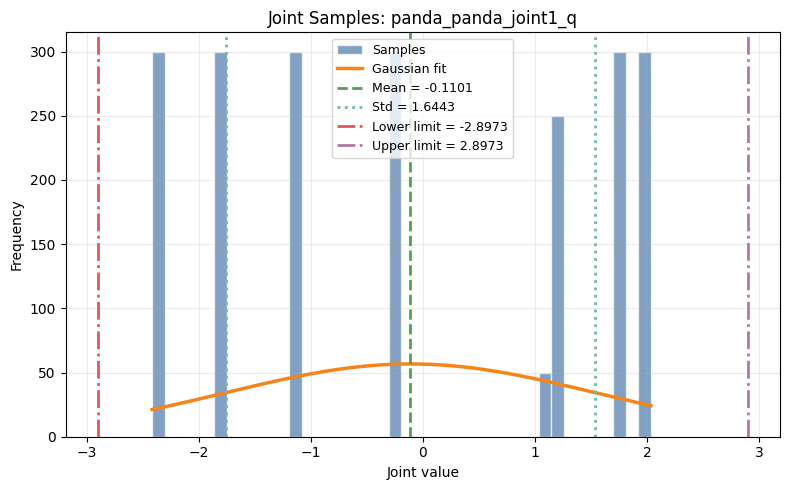

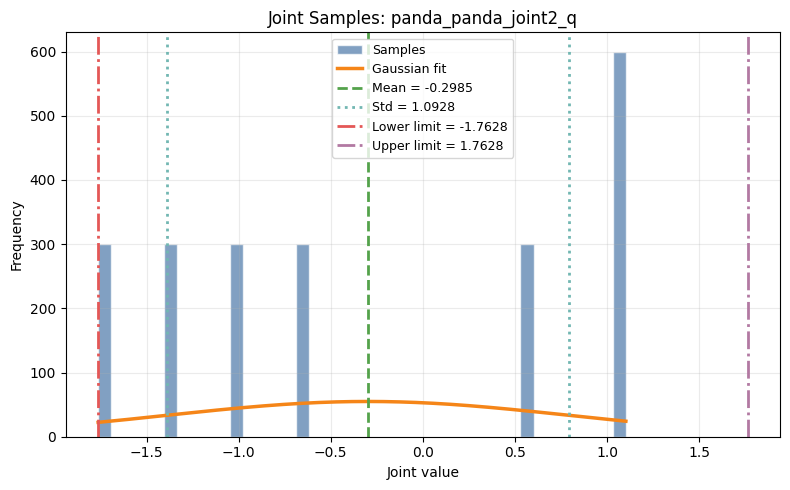

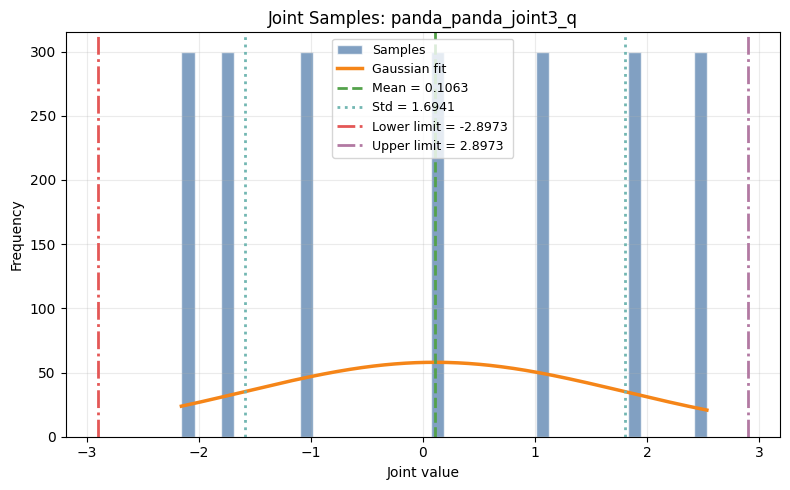

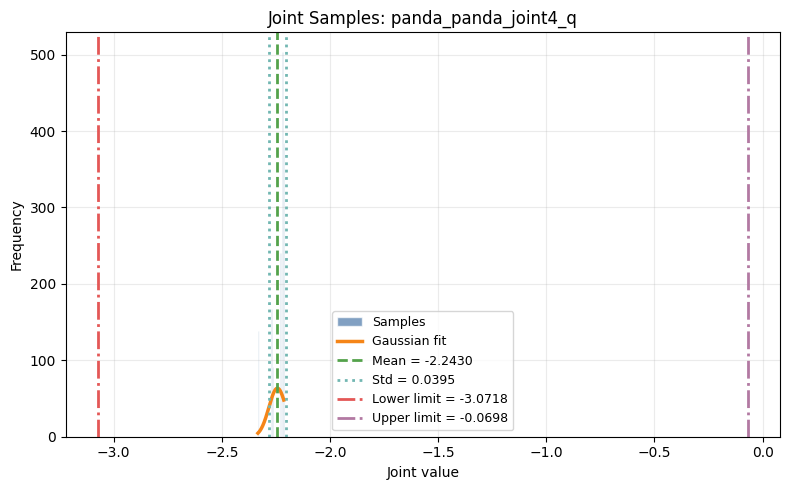

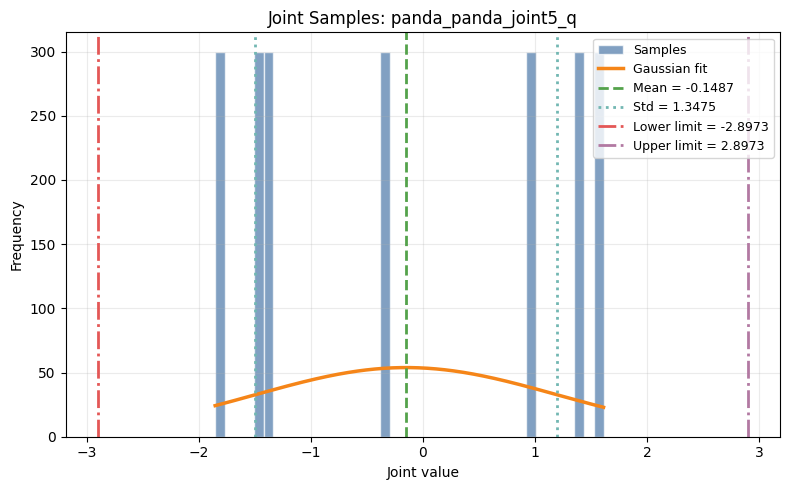

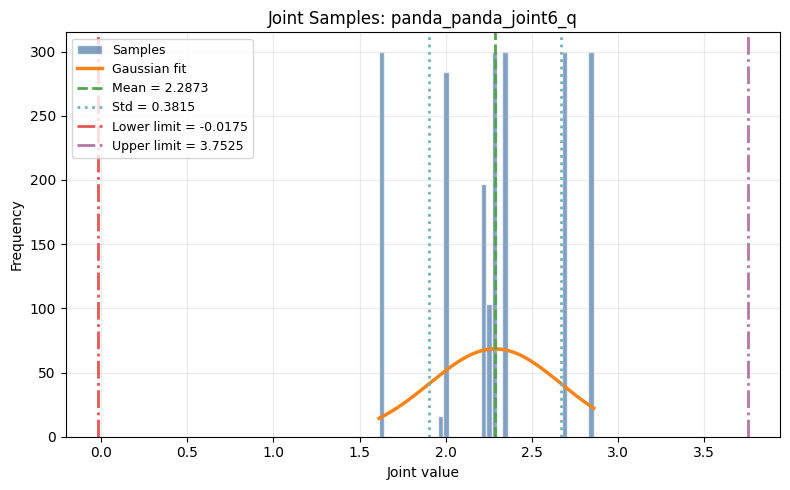

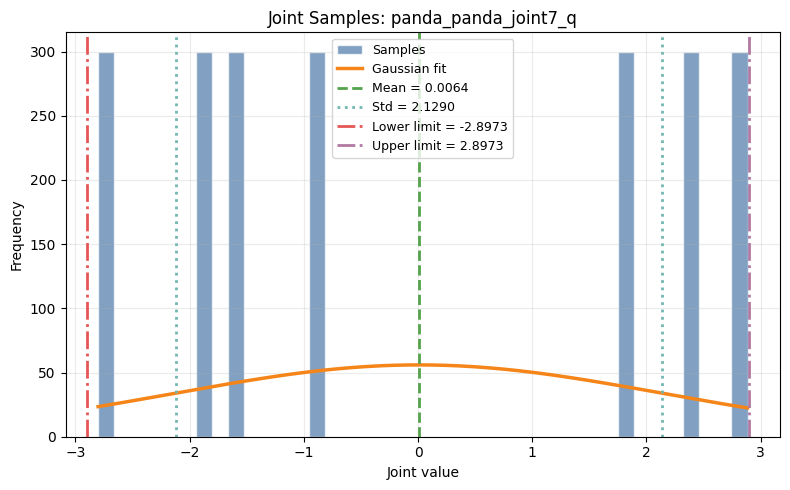

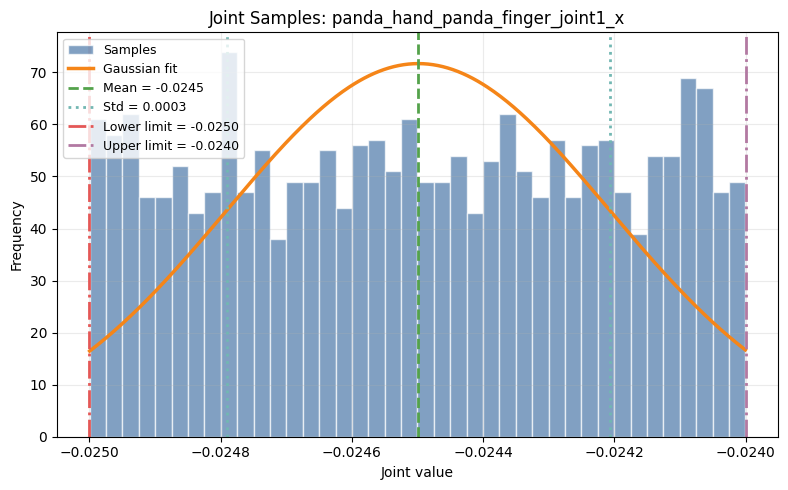

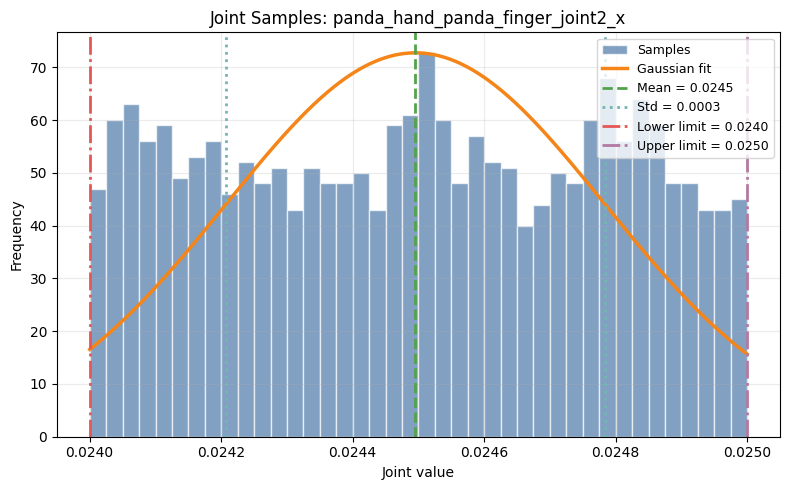

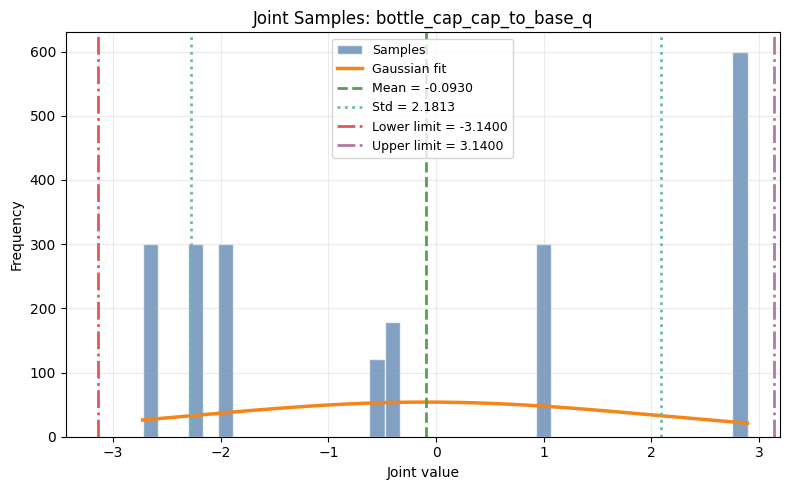

NHR note: Equality-aware NHR with restarts. Skipped old gripper grasp_mode polytope. h(q)=hand-cap position equality. g(q)=finger bounds plus optional axis alignment.
Saved joint sample artifacts to joint_samples_plots/20260729_202840
joint_samples_plots/20260729_202840


In [85]:
run_dir = save_joint_sample_artifacts(
    samples=samples,
    diagnostics=restart_info,
    lower=grasp_lower_joint_limits,
    upper=grasp_upper_joint_limits,
    joint_names=joint_names,
    options=nhr_options,
    output_root="joint_samples_plots",
    note=(
        "Equality-aware NHR with restarts. "
        "Skipped old gripper grasp_mode polytope. "
        "h(q)=hand-cap position equality. "
        "g(q)=finger bounds plus optional axis alignment."
    ),
    bins=40,
    show=True,
)

print(run_dir)

In [86]:
if len(samples) == 0:
    print("No samples to visualise.")
else:
    stride = max(1, len(samples) // 200)

    # for i, q in enumerate(samples):
    for i, q in enumerate(samples[::stride]):
        h_err = np.linalg.norm(h_grasp_eq(q), ord=np.inf)
        g_val = np.max(g_grasp_ineq(q))

        print(f"vis {i:03d} | h_inf={h_err:.3e} | g_max={g_val:.3e}")

        plant.SetPositions(plant_context, q)
        diagram.ForcedPublish(diagram_context)
        time.sleep(0.05)

vis 000 | h_inf=5.029e-05 | g_max=-1.070e-05
vis 001 | h_inf=5.029e-05 | g_max=-9.450e-05
vis 002 | h_inf=5.001e-05 | g_max=-6.143e-04
vis 003 | h_inf=5.013e-05 | g_max=-5.230e-04
vis 004 | h_inf=5.007e-05 | g_max=-9.053e-04
vis 005 | h_inf=5.028e-05 | g_max=-4.787e-04
vis 006 | h_inf=5.037e-05 | g_max=-1.660e-04
vis 007 | h_inf=5.036e-05 | g_max=-2.868e-04
vis 008 | h_inf=5.028e-05 | g_max=-3.887e-04
vis 009 | h_inf=5.020e-05 | g_max=-7.387e-04
vis 010 | h_inf=4.954e-05 | g_max=-1.000e-03
vis 011 | h_inf=4.872e-05 | g_max=-1.958e-03
vis 012 | h_inf=4.822e-05 | g_max=-8.715e-04
vis 013 | h_inf=4.827e-05 | g_max=-8.154e-04
vis 014 | h_inf=5.233e-05 | g_max=-1.644e-03
vis 015 | h_inf=5.178e-05 | g_max=-2.088e-03
vis 016 | h_inf=5.804e-05 | g_max=-2.273e-03
vis 017 | h_inf=5.787e-05 | g_max=-2.307e-03
vis 018 | h_inf=5.831e-05 | g_max=-2.401e-03
vis 019 | h_inf=5.816e-05 | g_max=-2.108e-03
vis 020 | h_inf=5.815e-05 | g_max=-1.827e-03
vis 021 | h_inf=5.811e-05 | g_max=-2.017e-03
vis 022 | 

In [87]:
# get current q from plant

q = plant.GetPositions(plant_context)

#check if current q meets g and h constraints

print("Current q:", q)
print("h(q):", h_grasp_eq(q))
print("g(q):", g_grasp_ineq(q))

# check if constraints are satisfied within tolerance
if np.allclose(h_grasp_eq(q), 0, atol=equality_tol):
    print("h(q) constraints satisfied.")
else:
    print("h(q) constraints NOT satisfied.")
    
if np.all(g_grasp_ineq(q) <= 0):
    print("g(q) constraints satisfied.")
else:
    print("g(q) constraints NOT satisfied.")

Current q: [-2.41032232 -0.67712375  2.52733091 -2.27107174  0.9358806   2.67645722
 -2.78615766 -0.02413774  0.02443855 -1.91681845]
h(q): [ 3.79849152e-05  5.23248251e-05 -3.82774196e-05  7.22673158e-06]
g(q): [-0.00122608 -0.00377392 -0.1       ]
h(q) constraints satisfied.
g(q) constraints satisfied.


In [91]:
#I want to check both h and g constraints for the current q but using a range of wrist joint values (joint 7, index 6), as they all should be met by both constraints.

for wrist_value in np.linspace(-np.pi, np.pi, num=50):  # Adjust the range and number of samples as needed
    q_test = q.copy()
    q_test[idx_wrist] = wrist_value  # Set the wrist joint value

    h_val = h_grasp_eq(q_test)
    g_val = g_grasp_ineq(q_test)

    h_satisfied = np.allclose(h_val, 0, atol=equality_tol)
    g_satisfied = np.all(g_val <= 0)
    joint_limits_satisfied = np.all((q_test >= grasp_lower_joint_limits) & (q_test <= grasp_upper_joint_limits))

    print(f"Wrist joint value: {wrist_value:.2f} | "
          f"h satisfied: {h_satisfied} | g satisfied: {g_satisfied} | Joint limits satisfied: {joint_limits_satisfied}")

Wrist joint value: -3.14 | h satisfied: True | g satisfied: True | Joint limits satisfied: False
Wrist joint value: -3.01 | h satisfied: True | g satisfied: True | Joint limits satisfied: False
Wrist joint value: -2.89 | h satisfied: True | g satisfied: True | Joint limits satisfied: True
Wrist joint value: -2.76 | h satisfied: True | g satisfied: True | Joint limits satisfied: True
Wrist joint value: -2.63 | h satisfied: True | g satisfied: True | Joint limits satisfied: True
Wrist joint value: -2.50 | h satisfied: True | g satisfied: True | Joint limits satisfied: True
Wrist joint value: -2.37 | h satisfied: True | g satisfied: True | Joint limits satisfied: True
Wrist joint value: -2.24 | h satisfied: True | g satisfied: True | Joint limits satisfied: True
Wrist joint value: -2.12 | h satisfied: True | g satisfied: True | Joint limits satisfied: True
Wrist joint value: -1.99 | h satisfied: True | g satisfied: True | Joint limits satisfied: True
Wrist joint value: -1.86 | h satisfied

In [ ]:
def rotation_angle_from_matrix(R):
    """
    Returns angle of rotation matrix R in radians.
    """
    cos_theta = (np.trace(R) - 1.0) / 2.0
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.arccos(cos_theta)


def joint_position_index(plant, joint_name, model_instance=None):
    if model_instance is None:
        joint = plant.GetJointByName(joint_name)
    else:
        joint = plant.GetJointByName(joint_name, model_instance)

    if joint.num_positions() != 1:
        raise ValueError(
            f"Joint {joint_name} has {joint.num_positions()} positions; "
            "this helper assumes a 1-DOF joint."
        )

    return joint.position_start()

In [ ]:
@dataclass
class ModeSpec:
    name: str
    A: np.ndarray
    b: np.ndarray
    indices: np.ndarray

    def inequalities(self, q):
        """
        Returns A q_reduced - b <= 0.
        """
        q_reduced = q[self.indices]
        return self.A @ q_reduced - self.b

In [ ]:
idx_wrist = joint_position_index(plant, "panda_joint7", panda_arm)
idx_f1 = joint_position_index(plant, "panda_finger_joint1", panda_hand)
idx_f2 = joint_position_index(plant, "panda_finger_joint2", panda_hand)
idx_cap = joint_position_index(plant, "cap_to_base", cap)

print(f"idx_wrist: {idx_wrist}, idx_f1: {idx_f1}, idx_f2: {idx_f2}, idx_cap: {idx_cap}")

# IMPORTANT: this order must match your existing grasp_polytope coordinates.
reduced_indices = np.array([
    idx_wrist,
    idx_f1,
    idx_f2,
    idx_cap,
])

In [ ]:
grasp_mode = ModeSpec(
    name="grasp_mode_0",
    A=np.asarray(grasp_polytope.A()),
    b=np.asarray(grasp_polytope.b()).reshape(-1),
    indices=reduced_indices,
)

print("A shape:", grasp_mode.A.shape)
print("num reduced indices:", len(grasp_mode.indices))

grasp_mode.A.shape[1] == len(grasp_mode.indices)

In [ ]:
@dataclass
class GraspPoseSpec:
    X_CapE_des: RigidTransform

    # Relative position bounds in cap frame.
    # Start generous, then tighten.
    p_lower: np.ndarray
    p_upper: np.ndarray

    # Orientation tolerance.
    theta_tol: float

    def inequalities(self, q, plant, plant_context, E, Cap):
        old_q = plant.GetPositions(plant_context).copy()
        plant.SetPositions(plant_context, q)

        X_WE = plant.CalcRelativeTransform(
            plant_context,
            plant.world_frame(),
            E,
        )
        X_WCap = plant.CalcRelativeTransform(
            plant_context,
            plant.world_frame(),
            Cap,
        )

        X_CapE = X_WCap.inverse().multiply(X_WE)

        p = X_CapE.translation()

        # Restore immediately.
        plant.SetPositions(plant_context, old_q)

        # Box constraints:
        # p_lower <= p <= p_upper
        g_pos = np.concatenate([
            self.p_lower - p,
            p - self.p_upper,
        ])

        # R_current = X_CapE.rotation().matrix()
        # R_des = self.X_CapE_des.rotation().matrix()
        # R_err = R_des.T @ R_current
        # theta_err = rotation_angle_from_matrix(R_err)

        # g_rot = np.array([
        #     theta_err - self.theta_tol
        # ])

        # return np.concatenate([g_pos, g_rot])
        return g_pos

In [ ]:
R_CapGoal = RotationMatrix(RollPitchYaw(np.pi, 0, 0))
X_CapGoal = RigidTransform(R_CapGoal, [0.0, 0.0, 0.105])

# TODO: REDUCE TOLERANCES TO 0.001 (1mm) once we have a good grasping solution. 
xy_tol = 0.01      # 1 cm lateral tolerance
z_tol = 0.05       # 1 cm vertical tolerance
z_des = 0.105

grasp_pose_spec = GraspPoseSpec(
    X_CapE_des=X_CapGoal,
    p_lower=np.array([-xy_tol, -xy_tol, z_des - z_tol]),
    p_upper=np.array([ xy_tol,  xy_tol, z_des + z_tol]),
    theta_tol=np.deg2rad(5),
)

In [ ]:
def g_grasp_full_arm(q):
    q = np.asarray(q, dtype=float)

    gs = []

    # 1. Lower-dimensional gripper-mode polytope lifted into full q.
    # gs.append(grasp_mode.inequalities(q))

    # 2. FK-based hand-cap pose tolerance.
    gs.append(
        grasp_pose_spec.inequalities(
            q=q,
            plant=plant,
            plant_context=plant_context,
            E=E,
            Cap=Cap,
        )
    )

    # 3. Optional explicit finger bounds.
    # Comment this out if already fully represented by grasp_mode.
    # gs.append(finger_spec.inequalities(q))

    return np.concatenate(gs)

In [ ]:
print(len(q_sol))

g_val = g_grasp_full_arm(q_sol)

print("num constraints:", len(g_val))
print("max violation:", np.max(g_val))
print("feasible:", np.all(g_val <= 1e-6))

for i, val in enumerate(g_val):
    print(i, val)

In [ ]:
def named_g_grasp_full_arm(q):
    q = np.asarray(q, dtype=float)

    names = []
    values = []

    # g_mode = grasp_mode.inequalities(q)
    # names += [f"mode_{i}" for i in range(len(g_mode))]
    # values += list(g_mode)

    g_pose = grasp_pose_spec.inequalities(
        q=q,
        plant=plant,
        plant_context=plant_context,
        E=E,
        Cap=Cap,
    )
    pose_names = [
        "x_lower", "y_lower", "z_lower",
        "x_upper", "y_upper", "z_upper",
        "orientation",
    ]
    names += pose_names
    values += list(g_pose)

    # g_fingers = finger_spec.inequalities(q)
    # finger_names = [
    #     "finger1_lower",
    #     "finger1_upper",
    #     "finger2_lower",
    #     "finger2_upper",
    # ]
    # names += finger_names
    # values += list(g_fingers)

    return names, np.asarray(values)

In [ ]:
names, vals = named_g_grasp_full_arm(q_sol)

for name, val in zip(names, vals):
    status = "OK" if val <= 1e-6 else "VIOLATED"
    print(f"{name:20s} {val: .6e}  {status}")

In [ ]:
from nhr import nhr_sample, NHROptions

In [ ]:
lower = plant.GetPositionLowerLimits()
upper = plant.GetPositionUpperLimits()

options = NHROptions(
    num_samples=2000,
    burn_in=100,
    thinning=100,

    delta_max=0.9,              # bigger than 0.02
    constraint_tol=1e-5,         # slightly looser for FK finite differences

    max_inner_tries=100,
    use_initial_linear_clip=False,   # less conservative while debugging

    finite_difference_step=1e-5,
    random_seed=0,
    verbose=True,
)

samples, diagnostics = nhr_sample(
    x0=q_sol,
    g=g_grasp_full_arm,
    lower=lower,
    upper=upper,
    Jg=None,
    f=lambda q: 0.0,
    extra_check=None,
    options=options,
)

In [ ]:
violations = np.array([np.max(g_grasp_full_arm(q)) for q in samples])

print("num samples:", len(samples))
print("max violation over samples:", np.max(violations))
print("mean max violation:", np.mean(violations))

## Visualise samples in the grasping space

In [ ]:
for i, (q, v) in enumerate(zip(samples, violations)):
    status = "OK" if v <= 1e-6 else "VIOLATED"
    print(f"sample {i:3d} max violation: {v:.6e}  {status}")
    # visualize in meshcat
    plant.SetPositions(plant_context, q)
    diagram.ForcedPublish(diagram_context)
    time.sleep(0.05)  # slow down for visualization
    # if i >= 500:
    #     break  # only visualize the first 500 samples

In [ ]:
# gather data of how much each joint changes across samples
# for each joint, print the index, name, lower limit, min, max, upper limit, mean, std, separated by tabs and fixed width formatting

joint_limits = visualizer.q_lower_limits, visualizer.q_upper_limits


# print header so that it matches the data below ':>4s' means right-align with width 4, ':>12s' means right-align with width 12
# print(f"{'idx':<4s} {'joint_name':<40s} {'lo':<7s} {'min':<7s} {'max':<10s} {'up':<10s} {'mean':<10s} {'std':<10s}")
print(f"{'idx':<4s} {'joint_name':<40s} {'lo':<7s} {'min':<7s} {'max':<7s} {'up':<7s} {'mean':<7s} {'std':<7s}")
for i, joint_name in enumerate(plant.GetPositionNames()):
    joint_positions = samples[:, i]
    lower_limit = joint_limits[0][i]
    upper_limit = joint_limits[1][i]
    min_pos = np.min(joint_positions)
    max_pos = np.max(joint_positions)
    mean_pos = np.mean(joint_positions)
    std_pos = np.std(joint_positions)
    print(f"{i:2d}   {joint_name:40s} {lower_limit: .4f} {min_pos: .4f} {max_pos: .4f} {upper_limit: .4f} {mean_pos: .4f} {std_pos: .4f}")

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from datetime import datetime

# Create the output directory if it doesn't exist.
output_dir = Path("joint_samples_plots")
output_dir.mkdir(parents=True, exist_ok=True)

# each time the cell is run, create a folder with a timestamp to save the plots on top of the above directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = output_dir / timestamp
output_dir.mkdir(parents=True, exist_ok=True)

joint_limits = visualizer.q_lower_limits, visualizer.q_upper_limits
joint_names = list(plant.GetPositionNames())

if "samples" not in globals():
    raise NameError("samples is not defined. Run the sampling cell before this plot cell.")

samples = np.asarray(samples)
if samples.ndim != 2:
    raise ValueError(f"Expected samples to be a 2D array, got shape {samples.shape}.")

for i, joint_name in enumerate(joint_names):
    values = samples[:, i]
    mean = float(np.mean(values))
    std = float(np.std(values, ddof=1))

    fig, ax = plt.subplots(figsize=(8, 5))
    counts, bins, _ = ax.hist(
        values,
        bins=30,
        density=False,
        alpha=0.7,
        color="#4c78a8",
        edgecolor="white",
        label="Samples",
    )

    if std > 0:
        x = np.linspace(bins[0], bins[-1], 400)
        bin_width = bins[1] - bins[0]
        pdf = norm.pdf(x, loc=mean, scale=std) * len(values) * bin_width
        ax.plot(x, pdf, color="#f58518", linewidth=2.5, label="Gaussian fit")

    ax.axvline(mean, color="#54a24b", linestyle="--", linewidth=2, label=f"Mean = {mean:.4f}")
    ax.axvline(mean - std, color="#72b7b2", linestyle=":", linewidth=2, label=f"Std = {std:.4f}")
    ax.axvline(mean + std, color="#72b7b2", linestyle=":", linewidth=2)

    lower_limit = joint_limits[0][i]
    upper_limit = joint_limits[1][i]
    ax.axvline(lower_limit, color="#e45756", linestyle="-.", linewidth=2, label=f"Lower limit = {lower_limit:.4f}")
    ax.axvline(upper_limit, color="#b279a2", linestyle="-.", linewidth=2, label=f"Upper limit = {upper_limit:.4f}")

    ax.set_title(f"Joint Samples: {joint_name}")
    ax.set_xlabel("Joint value")
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=9)
    fig.tight_layout()

    safe_name = "".join(c if c.isalnum() or c in "._-" else "_" for c in joint_name)
    fig.savefig(output_dir / f"{safe_name}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## Walk around free polytope

In [ ]:
def walk_through_free_space(planner, verbose=True):
    """ Randomly move the robot through the free polytopes to visualize the free space in meshcat. This is done through IK, selecting a random linear velocity for the end effector and solving for the next configuration. This will happen for each polytope in the free space. The robot will move through the free space until it reaches the last polytope. 
    
    verbose: If True, prints the current polytope index out of the total number of polytopes and the current configuration of the robot.
    """
    
    for i, poly in enumerate(planner.cs_free):
        if verbose:
            print(f"Moving through polytope {i+1}/{len(planner.cs_free)}")
        # Get the vertices of the polytope
        vertices = visualizer.get_polytope_vertices(poly)
        # Select a random vertex
        random_vertex = vertices[np.random.choice(vertices.shape[0])]
        # compute the corresponding end effector position in world frame through FK (import from drake)
        X_WE = planner.plant.CalcRelativeTransform(planner.plant_context, planner.plant.world_frame(), planner.plant.GetFrameByName("panda_hand", planner.model_instances[1]))
        random_vertex_translation = X_WE.translation()
        # Solve IK to move the robot to the random vertex
        q_sol, res = solve_ik_place_frame_at_pose(
            plant=planner.plant,
            plant_context=planner.plant_context,
            frame_B=planner.plant.GetFrameByName("panda_hand", planner.model_instances[1]),
            X_WG=RigidTransform(RotationMatrix(), random_vertex_translation),
            pos_tol=0.01,
            theta_tol=np.deg2rad(5),
            min_distance=None,
            q_seed=planner.plant.GetPositions(planner.plant_context)
        )
        if q_sol is not None:
            
            # for 5 seconds, move the robot around the polytope, and bounce off the walls of the polytope, while staying inside the polytope. This is done by selecting a random linear velocity for the end effector and solving for the next configuration using IK. If the next configuration is outside the polytope, select a new random linear velocity and try again. Repeat this process for 5 seconds.
            start_time = time.time()
            while time.time() - start_time < 5:
                # Get the current position of the end effector
                X_WE = planner.plant.CalcRelativeTransform(planner.plant_context, planner.plant.world_frame(), planner.plant.GetFrameByName("panda_hand", planner.model_instances[0]))
                # Select a random linear velocity for the end effector
                random_velocity = np.random.uniform(-0.01, 0.01, size=3)
                # Compute the next position of the end effector
                next_position = X_WE.translation() + random_velocity
                # Check if the next position is inside the polytope
                if poly.PointInSet(next_position):
                    # Solve IK to move the robot to the next position
                    q_sol, res = solve_ik_place_frame_at_pose(
                        plant=planner.plant,
                        plant_context=planner.plant_context,
                        frame_B=planner.plant.GetFrameByName("panda_hand", planner.model_instances[0]),
                        X_WG=RigidTransform(RotationMatrix(), next_position),
                        pos_tol=0.01,
                        theta_tol=np.deg2rad(5),
                        min_distance=None,
                        q_seed=planner.plant.GetPositions(planner.plant_context)
                    )
                    if q_sol is not None:
                        planner.plant.SetPositions(planner.plant_context, q_sol)
                        planner.diagram.ForcedPublish(planner.diagram_context)
                        
                        
        else:
            if verbose:
                print(f"IK failed for polytope {i+1}/{len(planner.cs_free)}")
    
    

In [ ]:
walk_through_free_space(planner, verbose=True)

In [ ]:
# planner.visualize_cspace(factor=1, num_points=30, filled_polytopes=planner.cs_free)

In [ ]:
from pydrake.geometry.optimization import LoadIrisRegionsYamlFile
import numpy as np

path_148 = np.load(
    "path_drake_1_48.npy"
)

# traj = planner._generate_trajectory(path_148)

regions_dict_148 = LoadIrisRegionsYamlFile(
    "cfree_drake_1_48.yaml"
)
regions_dict_149 = LoadIrisRegionsYamlFile(
    "cfree_drake_1_49.yaml"
)

old_regions = list(regions_dict_148.values())
new_regions = list(regions_dict_149.values())

print("Number of free regions loaded:", len(old_regions))
print("Number of regions in the planner's c_free:", len(new_regions))

# planner.visualize_cspace(factor=1, num_points=30, filled_polytopes=free_regions)


In [ ]:
# print("Assert old and new free regions are the same or very similar")

# assert len(old_regions) == len(new_regions), "The number of free regions is different"


# old_vertices_list = []
# new_vertices_list = []

# for i, (old_region, new_region) in enumerate(zip(old_regions, new_regions)):
#     old_vertices = visualizer.get_polytope_vertices(old_region)
#     new_vertices = visualizer.get_polytope_vertices(new_region)
    
#     # list of old a new vertices
#     old_vertices_list.append(old_vertices)
#     new_vertices_list.append(new_vertices)
    
# # sort the vertices by the first coordinate of their shape to ensure consistent ordering for comparison
# old_vertices_list_sorted = sorted(old_vertices_list, key=lambda v: v.shape[0])
# new_vertices_list_sorted = sorted(new_vertices_list, key=lambda v: v.shape[0])

# # Compare the sorted vertices of each region
# for i, (old_vertices, new_vertices) in enumerate(zip(old_vertices_list_sorted, new_vertices_list_sorted)):
    
#     assert old_vertices.shape == new_vertices.shape, f"Region {i} vertices have different shapes: {old_vertices.shape} vs {new_vertices.shape}"
    
#     if not np.allclose(old_vertices, new_vertices, atol=1e-5):
#         print(f"Region {i} vertices are different.")
#         print("Old vertices:\n", old_vertices)
#         print("New vertices:\n", new_vertices)
#     else:
#         print(f"Region {i} vertices are the same or very similar.")


# q0 = path_148[0]
# q1 = path_148[1]

# def max_region_violation(region, q):
#     """
#     For A q <= b:
#         <= 0  means inside
#         > 0   means outside
#     """
#     q = np.asarray(q).reshape(-1)
#     return float(np.max(region.A() @ q - region.b()))


# q0_violations_old = np.array([
#     max_region_violation(region, q0)
#     for region in old_regions
# ])

# q0_violations_new = np.array([
#     max_region_violation(region, q0)
#     for region in new_regions
# ])

# q1_violations_old = np.array([
#     max_region_violation(region, q1)
#     for region in old_regions
# ])
# q1_violations_new = np.array([
#     max_region_violation(region, q1)
#     for region in new_regions
# ])


# print("q0 =", q0)
# print("q1 =", q1)



# print("\nBest q0 regions:")
# for i, j in zip(np.argsort(q0_violations_old)[:5], np.argsort(q0_violations_new)[:5]):
#     print(
#         f"  (old) region {i:2d}: "
#         f"max(Aq-b) = {q0_violations_old[i]:+.16e}"
#     )
#     print(
#         f"  (new) region {j:2d}: "
#         f"max(Aq-b) = {q0_violations_new[j]:+.16e}"
#     )

# print("\nBest q1 regions:")
# for i, j in zip(np.argsort(q1_violations_old)[:5], np.argsort(q1_violations_new)[:5]):
#     print(
#         f"  (old) region {i:2d}: "
#         f"max(Aq-b) = {q1_violations_old[i]:+.16e}"
#     )
#     print(
#         f"  (new) region {j:2d}: "
#         f"max(Aq-b) = {q1_violations_new[j]:+.16e}"
#     )

In [ ]:
# planner.cs_free = old_regions

q0 = path_148[0]
q1 = path_148[1]


# for weight in [
#     1e-6,
#     1e-5,
#     1e-4,
#     1e-3,
#     1e-2,
#     1e-1,
#     1.0,
#     10.0,
# ]:
#     print("\n")
#     print("=" * 70)
#     print("PATH LENGTH WEIGHT:", weight)
#     print("=" * 70)

traj, result = planner._generate_edge_trajectory(
    q0,
    q1
)

print(
    "FINAL RESULT:",
    result.get_solution_result(),
)

In [ ]:
    # x_init = np.array([-3.14, -0.78, -0.03]) # [cap angle, gripper angle, finger translation]
    # x_goal = np.array([3.14, -0.78, -0.03])

# switch to gripper angle, finger translation, cap angle for planner
x_init = np.array([-0.72, -0.03, -3.14]) # [gripper angle, finger translation, cap angle]
x_goal = np.array([-0.72, -0.03, 3.14])

print(visualizer.check_collision_q_by_ik(x_init))
print(visualizer.check_collision_q_by_ik(x_goal))
path, traj = planner.compute_trajectory(x_init, x_goal)

In [ ]:
planner.plant.SetPositions(planner.plant_context, x_init)
traj_path = planner.display_trajectory(traj, plotly=True)


In [ ]:
# from pydrake.geometry.optimization import SaveIrisRegionsYamlFile

# SaveIrisRegionsYamlFile(
#     "cfree_drake_1_48.yaml",
#     {
#         f"region_{i:03d}": region
#         for i, region in enumerate(planner.cs_free)
#     },
# )

# np.save(
#     "path_drake_1_49.npy",
#     path,
# )